In [1]:
# Standard library
import os
import re
import sys
import warnings
from pathlib import Path
import rasterio

# Third-party - Data and scientific computing
import contextily as cx
import geopandas as gpd
import igraph as ig
import numpy as np
import pandas as pd
import xarray as xr
from pyproj import Geod
from tqdm import tqdm
from damagescanner.core import DamageScanner

#  Shapely-specific imports for spatial analysis
import shapely
from shapely import STRtree
from shapely.geometry import LineString, MultiLineString, Point
from shapely.ops import nearest_points, snap

# Matplotlib-specific imports for figures
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import FuncFormatter, MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Suppress warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

In [2]:
BASE_DIR = Path.cwd().parent  
data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
intermediate_results_path = BASE_DIR / 'intermediate_results'

In [3]:
gdf_results = gpd.read_parquet(intermediate_results_path / "criticality_results.parquet")

In [4]:
gdf_deonice = gpd.read_file(data_path / "Deonice_Februar_2025.shp")

# --- Define core Serbia (excluding Kosovo) ---
world_path = data_path / "ne_10m_admin_0_countries.shp"
world = gpd.read_file(world_path)

serbia = world.loc[world.SOV_A3 == 'SRB']
kosovo = world.loc[world.SOV_A3 == 'KOS']

serbia_only = gpd.overlay(serbia, kosovo, how='difference').to_crs(gdf_deonice.crs)

# --- Filter Deonice to core Serbia only ---
gdf_deonice = gpd.sjoin(
    gdf_deonice,
    serbia_only[["geometry"]],
    how="inner",
    predicate="within"
).drop(columns=["index_right"])

# --- Identify rows in Deonice not present in gdf_results ---
existing_ids = set(gdf_results["oznaka_deo"])
mask_new = ~gdf_deonice["oznaka_deo"].isin(existing_ids)
gdf_new_rows = gdf_deonice[mask_new].copy()

# --- Keep only columns that exist in gdf_results ---
shared_cols = [col for col in gdf_results.columns if col in gdf_new_rows.columns]
cols_only_in_results = [col for col in gdf_results.columns if col not in gdf_new_rows.columns]

gdf_new_rows = gdf_new_rows[shared_cols].copy()

# --- Fill columns that exist in gdf_results but not in Deonice ---
for col in cols_only_in_results:
    if gdf_results[col].dtype == object:
        gdf_new_rows[col] = ""
    else:
        gdf_new_rows[col] = 0

# --- Reorder columns to match gdf_results ---
gdf_new_rows = gdf_new_rows[gdf_results.columns]

# --- Concatenate ---
gdf_merged = pd.concat([gdf_results, gdf_new_rows], ignore_index=True)
gdf_merged = gpd.GeoDataFrame(gdf_merged, geometry="geometry", crs=gdf_results.crs)

# --- Summary ---
n_original = len(gdf_results)
n_deonice_total = len(gdf_deonice) + mask_new.shape[0] - len(gdf_deonice)  # pre-filter total not tracked here
n_outside_serbia = (~gdf_deonice["oznaka_deo"].isin(gdf_deonice["oznaka_deo"])) # placeholder
n_new = len(gdf_new_rows)
n_skipped = (~mask_new).sum()

print("=== Merge Summary ===")
print(f"Original gdf_results rows:          {n_original}")
print(f"Deonice rows after Serbia filter:   {len(gdf_deonice)}")
print(f"Deonice rows already in results:    {n_skipped}  (skipped)")
print(f"New rows added from Deonice:        {n_new}")
print(f"Total rows in merged GeoDataFrame:  {len(gdf_merged)}")
print(f"Columns filled with 0 for new rows: {[c for c in cols_only_in_results if gdf_results[c].dtype != object] or 'none'}")

=== Merge Summary ===
Original gdf_results rows:          3135
Deonice rows after Serbia filter:   1762
Deonice rows already in results:    1672  (skipped)
New rows added from Deonice:        90
Total rows in merged GeoDataFrame:  3225
Columns filled with 0 for new rows: ['from_id', 'to_id', 'id', 'passenger_cars', 'buses', 'light_trucks', 'medium_trucks', 'heavy_trucks', 'articulated_vehicles', 'total_aadt', 'road_length', 'speed', 'fft', 'edge_no', 'pct_isolated', 'pct_unaffected', 'pct_delayed', 'average_time_disruption', 'average_dist_disruption', 'distance_disruption', 'time_disruption', 'vhl', 'phl', 'thl', 'pkl', 'tkl']


In [5]:
gdf_results = gdf_merged

In [6]:
# Load country outline
world_path =  data_path / "ne_10m_admin_0_countries.shp"
world = gpd.read_file(world_path)
country_plot = world.loc[world.SOV_A3 == 'SRB']

# read flood data
flood_path = data_path / "Europe_RP100_filled_depth.tif"

country_bounds = world.loc[world.SOV_A3 == 'SRB'].bounds

hazard_map = xr.open_dataset(flood_path, engine="rasterio")
hazard_country = hazard_map.rio.clip_box(minx=country_bounds.minx.values[0],
                 miny=country_bounds.miny.values[0],
                 maxx=country_bounds.maxx.values[0],
                 maxy=country_bounds.maxy.values[0]
                ).load()

exposed_roads = DamageScanner(
    hazard_country, 
    gdf_results, 
    curves=pd.DataFrame(), 
    maxdam=pd.DataFrame()
).exposure(asset_type='roads',disable_progress=False,return_full=False)


convert coverage to meters: 100%|██████████| 1334/1334 [00:02<00:00, 595.38it/s] 


In [7]:
def flagged_exposed_segments(row):
        return any(val > 0.25 for val in row['values'])

def max_depth(row):
        return np.max(row['values'])

exposed_roads['exposed'] = exposed_roads.progress_apply(flagged_exposed_segments, axis=1)
exposed_roads['max_depth'] =  exposed_roads.progress_apply(max_depth, axis=1)

convert coverage to meters: 100%|██████████| 1334/1334 [00:00<00:00, 129449.63it/s]


In [8]:
cat_map = {
    'A1': 'IA',
    'A2': 'IA',
    'A3': 'IA',
    'A4': 'IA',
    '39': 'IB'
}

mask = exposed_roads['kategorija'].isna()
exposed_roads.loc[mask, 'kategorija'] = exposed_roads.loc[mask, 'oznaka_put'].map(cat_map)

In [9]:
vertical_coordinates_path = data_path / "Vertical coordinates" / "RSDP_Feb_2026" / "RSDP_Feb_2026" / "Deonice"
vertical_coordinates = gpd.read_file(vertical_coordinates_path / "RSDP_Deonice_Feb_2026.shp")

# Strict filter: only keep roads where ALL vertices have non-zero Z
def has_complete_z(geom):
    if geom.geom_type == 'MultiLineString':
        z = [c[2] for line in geom.geoms for c in line.coords]
    else:
        z = [c[2] for c in geom.coords]
    return all(v != 0 for v in z) and len(z) > 1

vertical_coordinates = vertical_coordinates[vertical_coordinates.geometry.apply(has_complete_z)].copy()

vertical_coordinates['z_min'] = vertical_coordinates.geometry.apply(
    lambda g: min(c[2] for line in g.geoms for c in line.coords) if g.geom_type == 'MultiLineString' 
    else min(c[2] for c in g.coords))
vertical_coordinates['z_max'] = vertical_coordinates.geometry.apply(
    lambda g: max(c[2] for line in g.geoms for c in line.coords) if g.geom_type == 'MultiLineString' 
    else max(c[2] for c in g.coords))
vertical_coordinates['z_range'] = vertical_coordinates['z_max'] - vertical_coordinates['z_min']

# Reproject
vertical_coordinates_h = vertical_coordinates.set_crs(epsg=3909, allow_override=True)
vertical_coordinates_4326 = vertical_coordinates_h.to_crs(epsg=4326)

print(f"Roads with complete Z profiles: {len(vertical_coordinates)}")

c:\Users\yma794\AppData\Local\miniforge3\envs\criticality_env\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


Roads with complete Z profiles: 153


In [10]:
def extract_profiles(gdf_metric, gdf_4326, dem_path=data_path / 'dem_serbia.tif'):
    all_distances = []
    all_z_values = []
    all_dem_values = []
    
    with rasterio.open(dem_path) as src:
        dem_data = src.read(1)
        
        for idx in tqdm(range(len(gdf_metric)), desc='Extracting profiles'):
            geom_m = gdf_metric.geometry.iloc[idx]
            if geom_m.geom_type == 'MultiLineString':
                coords_m = [c for line in geom_m.geoms for c in line.coords]
            else:
                coords_m = list(geom_m.coords)
            
            distances = [0]
            for i in range(1, len(coords_m)):
                dx = coords_m[i][0] - coords_m[i-1][0]
                dy = coords_m[i][1] - coords_m[i-1][1]
                distances.append(distances[-1] + (dx**2 + dy**2)**0.5)
            distances = [d / 1000 for d in distances]
            
            z_values = [c[2] if c[2] != 0 else np.nan for c in coords_m]
            
            geom_4326 = gdf_4326.geometry.iloc[idx]
            if geom_4326.geom_type == 'MultiLineString':
                coords_4326 = [c for line in geom_4326.geoms for c in line.coords]
            else:
                coords_4326 = list(geom_4326.coords)
            
            dem_values = []
            for c in coords_4326:
                try:
                    row, col = src.index(c[0], c[1])
                    val = dem_data[row, col]
                    dem_values.append(val / 1000 if val != src.nodata else np.nan)
                except (IndexError, ValueError):
                    dem_values.append(np.nan)
            
            all_distances.append(distances)
            all_z_values.append(z_values)
            all_dem_values.append(dem_values)
    
    gdf_metric['distances_km'] = all_distances
    gdf_metric['z_profile'] = all_z_values
    gdf_metric['dem_profile'] = all_dem_values
    
    return gdf_metric

vertical_coordinates = extract_profiles(vertical_coordinates, vertical_coordinates_4326)

Extracting profiles: 100%|██████████| 153/153 [00:01<00:00, 86.26it/s] 


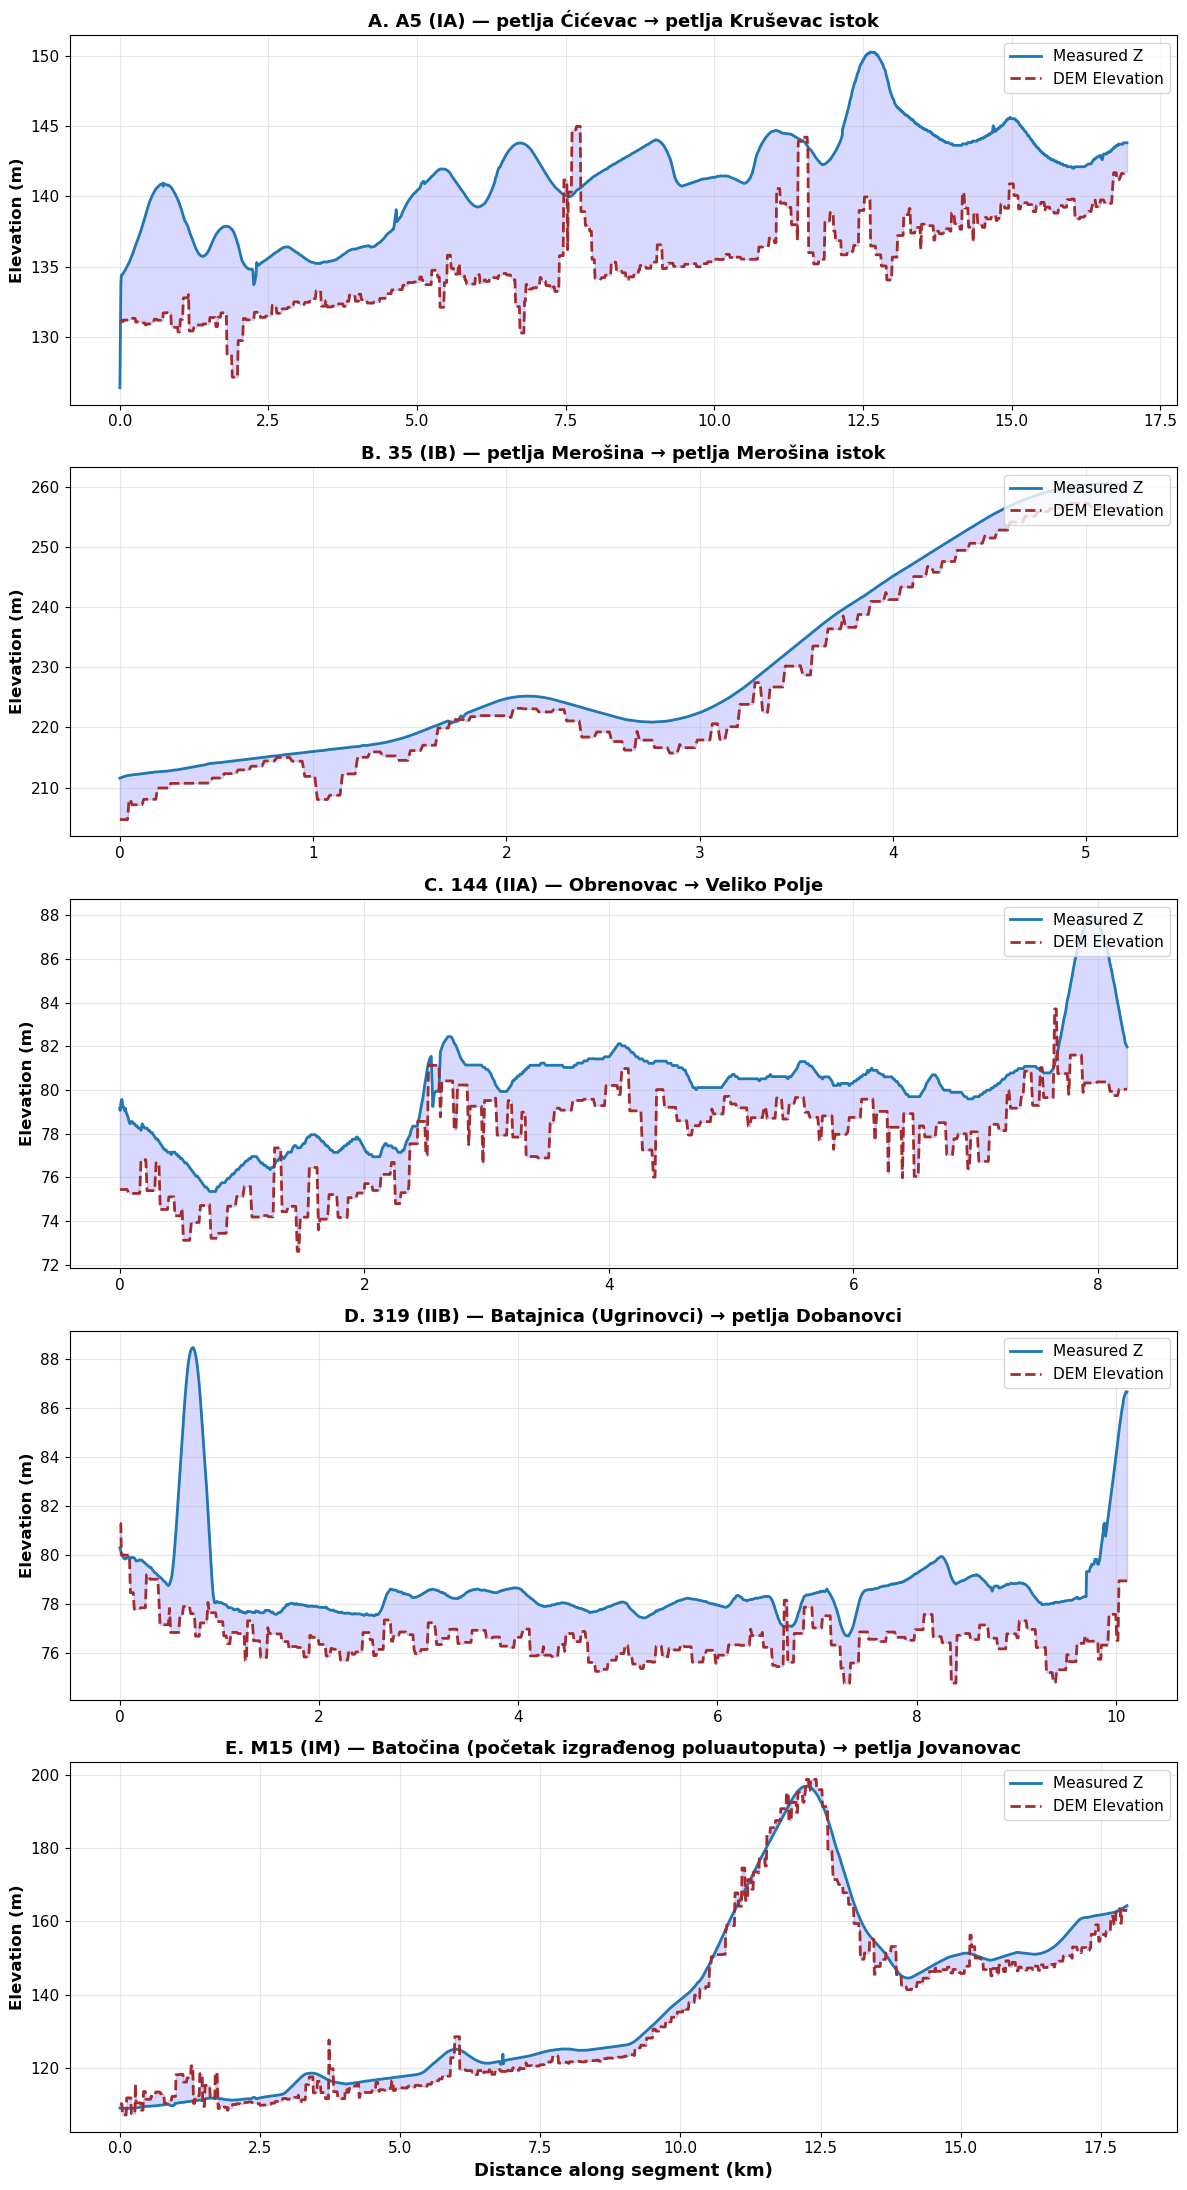

In [11]:
examples = {'IA': 188, 'IB': 1832, 'IIA': 1881, 'IIB': 1578, 'IM': 453}

fig, axes = plt.subplots(5, 1, figsize=(12, 22))

panels = ['A.', 'B.', 'C.', 'D.', 'E.']

for i, (cat, idx) in enumerate(examples.items()):
    row = vertical_coordinates.loc[idx]
    
    axes[i].plot(row['distances_km'], row['z_profile'], label='Measured Z', linewidth=2)
    axes[i].plot(row['distances_km'], row['dem_profile'], label='DEM Elevation', linewidth=2, linestyle='--', color='brown')
    
    axes[i].fill_between(row['distances_km'], row['z_profile'], row['dem_profile'], 
                         alpha=0.15, color='blue', where=[not (np.isnan(z) or np.isnan(d)) 
                         for z, d in zip(row['z_profile'], row['dem_profile'])])
    
    title = f"{panels[i]} {row['PutOzn']} ({row['PutKateg']}) — {row['CvorPocNaz']} → {row['CvorZavNaz']}"
    
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Elevation (m)', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=11, loc='upper right')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(labelsize=11)

axes[-1].set_xlabel('Distance along segment (km)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(figure_path / 'elevation_profiles_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# First, compute summary stats for all rows that have Z data
has_z = vertical_coordinates['z_profile'].apply(lambda z: sum(1 for v in z if not np.isnan(v)) > 5)
subset = vertical_coordinates[has_z].copy()

print(f"Roads with Z data: {has_z.sum()}")

# Compute stats per road
subset['mean_diff'] = subset.apply(
    lambda row: np.nanmean([z - d for z, d in zip(row['z_profile'], row['dem_profile']) 
                            if not (np.isnan(z) or np.isnan(d))]), axis=1)

subset['median_diff'] = subset.apply(
    lambda row: np.nanmedian([z - d for z, d in zip(row['z_profile'], row['dem_profile']) 
                              if not (np.isnan(z) or np.isnan(d))]), axis=1)

subset['std_diff'] = subset.apply(
    lambda row: np.nanstd([z - d for z, d in zip(row['z_profile'], row['dem_profile']) 
                           if not (np.isnan(z) or np.isnan(d))]), axis=1)

# DEM terrain characteristics
subset['dem_min'] = subset['dem_profile'].apply(lambda d: np.nanmin(d))
subset['dem_max'] = subset['dem_profile'].apply(lambda d: np.nanmax(d))
subset['dem_range'] = subset['dem_max'] - subset['dem_min']
subset['dem_mean'] = subset['dem_profile'].apply(lambda d: np.nanmean(d))

# Slope proxy: elevation range / road length
subset['road_length_km'] = subset['distances_km'].apply(lambda d: max(d))
subset['dem_slope'] = subset['dem_range'] / subset['road_length_km']

Roads with Z data: 151


In [13]:
# Median bias by category (more robust than mean with outliers)
bias_table = subset.groupby('PutKateg')['mean_diff'].agg(['median', 'mean', 'std', 'count'])
clean = subset[subset['mean_diff'].abs() < 20]
bias_lookup = clean.groupby('PutKateg')['mean_diff'].median().to_dict()
print(bias_lookup)

{'IA': 4.601053571428055, 'IB': 2.5885321098498104, 'IIA': 0.6095876782079163, 'IIB': 1.1351122123893485, 'IM': 3.659322115384341}


In [14]:
from scipy import stats

# Confidence intervals per category
ci_results = []
for cat, group in clean.groupby('PutKateg'):
    data = group['mean_diff'].dropna()
    n = len(data)
    median = data.median()
    mean = data.mean()
    std = data.std()
    
    # 95% CI for the mean
    ci_mean = stats.t.interval(0.95, df=n-1, loc=mean, scale=std/np.sqrt(n))
    
    # Bootstrap 95% CI for the median
    np.random.seed(42)
    boot_medians = [np.median(np.random.choice(data.values, size=n, replace=True)) for _ in range(10000)]
    ci_median = np.percentile(boot_medians, [2.5, 97.5])
    
    ci_results.append({
        'PutKateg': cat,
        'n': n,
        'median': median,
        'median_ci_low': ci_median[0],
        'median_ci_high': ci_median[1],
        'mean': mean,
        'mean_ci_low': ci_mean[0],
        'mean_ci_high': ci_mean[1]
    })

ci_df = pd.DataFrame(ci_results)
print(ci_df.to_string(index=False))

PutKateg  n   median  median_ci_low  median_ci_high      mean  mean_ci_low  mean_ci_high
      IA 35 4.601054       3.998717        5.591072  4.768886     4.207295      5.330478
      IB 22 2.588532       0.039983        3.422338  1.999851     0.807977      3.191724
     IIA 35 0.609588      -0.863578        0.896040 -0.430597    -1.700040      0.838847
     IIB 13 1.135112      -0.664770        3.531355  0.471914    -3.496995      4.440824
      IM 42 3.659322       3.253271        4.375735  3.615684     2.889432      4.341937


In [15]:
pooled = clean[clean['PutKateg'].isin(['IIA', 'IIB'])]
n = len(pooled)
median = pooled['mean_diff'].median()

np.random.seed(42)
boot = [np.median(np.random.choice(pooled['mean_diff'].values, size=n, replace=True)) for _ in range(10000)]
ci = np.percentile(boot, [2.5, 97.5])

print(f"Pooled IIA+IIB (n={n})")
print(f"Median: {median:.2f} m")
print(f"95% CI: [{ci[0]:.2f}, {ci[1]:.2f}]")

Pooled IIA+IIB (n=48)
Median: 0.64 m
95% CI: [-0.31, 1.07]


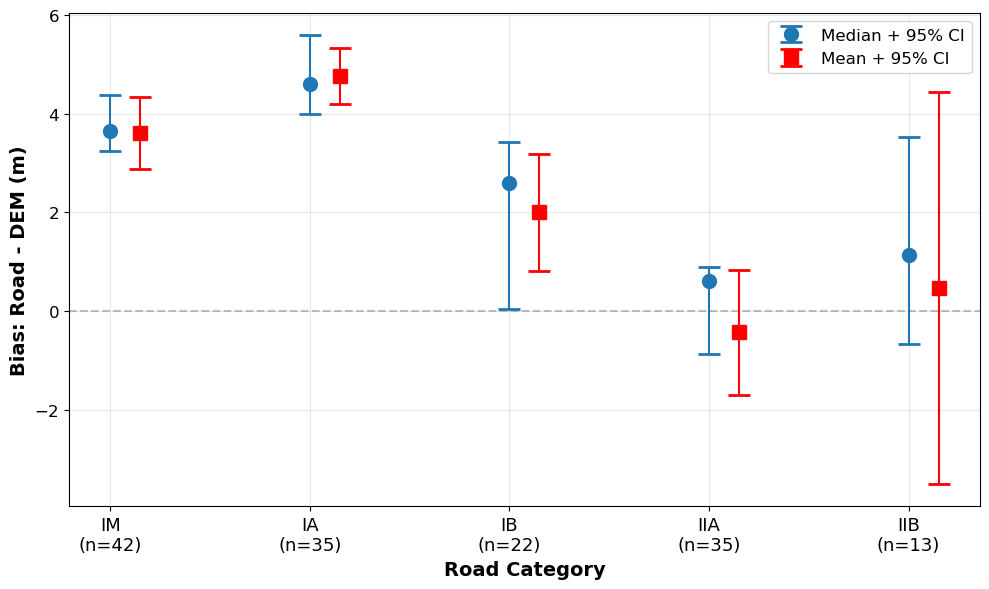

In [16]:
category_order = ['IM', 'IA', 'IB', 'IIA', 'IIB']
ci_df = ci_df.set_index('PutKateg').loc[category_order].reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(ci_df))
labels = [f"{row['PutKateg']}\n(n={row['n']})" for _, row in ci_df.iterrows()]
ax.errorbar(x, ci_df['median'], 
            yerr=[ci_df['median'] - ci_df['median_ci_low'], 
                  ci_df['median_ci_high'] - ci_df['median']],
            fmt='o', capsize=8, capthick=2, markersize=10, label='Median + 95% CI', zorder=3)
ax.errorbar([i + 0.15 for i in x], ci_df['mean'],
            yerr=[ci_df['mean'] - ci_df['mean_ci_low'],
                  ci_df['mean_ci_high'] - ci_df['mean']],
            fmt='s', capsize=8, capthick=2, markersize=10, color='red', label='Mean + 95% CI', zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=13)
ax.set_xlabel('Road Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Bias: Road - DEM (m)', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='grey', linestyle='--', alpha=0.5)
ax.legend(fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figure_path / 'elevation_bias_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
final_bias = {
    'IA': 4.601,
    'IM': 3.659,
    'IB': 0.82,
    'IIA': 0.82,
    'IIB': 0.82
}

exposed_roads['bias'] = exposed_roads['kategorija'].map(final_bias)
exposed_roads['corrected_max_depth'] = (exposed_roads['max_depth'] - exposed_roads['bias']).clip(lower=0)

summary = exposed_roads.groupby('kategorija').agg(
    total=('max_depth', 'count'),
    originally_flooded=('max_depth', lambda x: (x > 0).sum()),
    still_flooded=('corrected_max_depth', lambda x: (x > 0).sum()),
    bias=('bias', 'first'),
    avg_original_depth=('max_depth', 'mean'),
    avg_corrected_depth=('corrected_max_depth', 'mean')
).reset_index()
summary['removed'] = summary['originally_flooded'] - summary['still_flooded']
summary['pct_removed'] = (summary['removed'] / summary['originally_flooded'] * 100).round(1)
print(summary.to_string(index=False))

kategorija  total  originally_flooded  still_flooded  bias  avg_original_depth  avg_corrected_depth  removed  pct_removed
        IA    417                 417             79 4.601            2.758803             0.428376      338         81.1
        IB    341                 341            323 0.820            4.983499             4.177091       18          5.3
       IIA    407                 407            351 0.820            4.031656             3.259961       56         13.8
       IIB    110                 110             91 0.820            3.499400             2.731009       19         17.3
        IM     53                  53             18 3.659            3.380321             1.027906       35         66.0


In [18]:
exposed_roads

,from_id,to_id,objectid,oznaka_deo,smer_gdf1,kategorija,oznaka_put,oznaka_poc,naziv_poce,oznaka_zav,...,phl,thl,pkl,tkl,coverage,values,exposed,max_depth,bias,corrected_max_depth
4,12,13,5.0,A1023,D,IA,A1,A111,petlja Novi Sad sever,A112,...,823.760476,971.191387,78248.677851,92253.081020,"[7.98187616196413, 70.26538601103236, 69.90608...","[0.13600000739097595, 0.7319999933242798, 0.73...",True,1.663,4.601,0.000
6,16,17,8.0,A1004,L,IA,A1,A102,petlja Subotica sever,A101,...,39.989176,43.192538,3744.417620,4044.366883,"[88.6440373255492, 88.51560155956756, 88.42867...","[1.0, 0.43799999356269836, 0.4399999976158142,...",True,1.000,4.601,0.000
10,20,21,9.0,A1024,L,IA,A1,A112,petlja Novi Sad centar,A111,...,621.689310,732.954931,59068.276237,69639.904763,"[65.32851164404711, 67.4971709839168, 67.11328...","[0.7319999933242798, 0.7310000061988831, 0.828...",True,1.663,4.601,0.000
13,25,26,11.0,A1006,L,IA,A1,A103,petlja Subotica istok,A102,...,384.021433,433.885382,37145.367226,41968.573757,[77.13776407862304],[1.0],True,1.000,4.601,0.000
23,36,37,15.0,A1009,D,IA,A1,A104,petlja Subotica jug,A105,...,83.627869,90.283741,7874.714745,8501.456711,[91.49012157991058],[1.7929999828338623],True,1.793,4.601,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3204,0,0,1398.0,19602,,IIA,196,2130,Arilje,19503,...,0.000000,0.000000,0.000000,0.000000,"[43.45029399793323, 87.27022708531138, 88.1485...","[3.51200008392334, 0.25699999928474426, 3.1600...",True,12.521,0.820,11.701
3207,0,0,1514.0,22601,,IIA,226,21604,Prokuplje (Žitorađa),22601,...,0.000000,0.000000,0.000000,0.000000,"[62.825116788868876, 66.05985283448938]","[0.9300000071525574, 4.074999809265137]",True,4.075,0.820,3.255
3209,0,0,1614.0,M7032,,IM,M7,M716,Golubac (Maleševo),M715,...,0.000000,0.000000,0.000000,0.000000,[47.62400273212873],[0.5659999847412109],True,0.566,3.659,0.000
3211,0,0,1630.0,M7098,,IM,M7,M715,Radoševac,M791,...,0.000000,0.000000,0.000000,0.000000,"[81.80837575828782, 81.80989871329855, 81.8695...","[0.5659999847412109, 0.5659999847412109, 0.565...",True,2.766,3.659,0.000


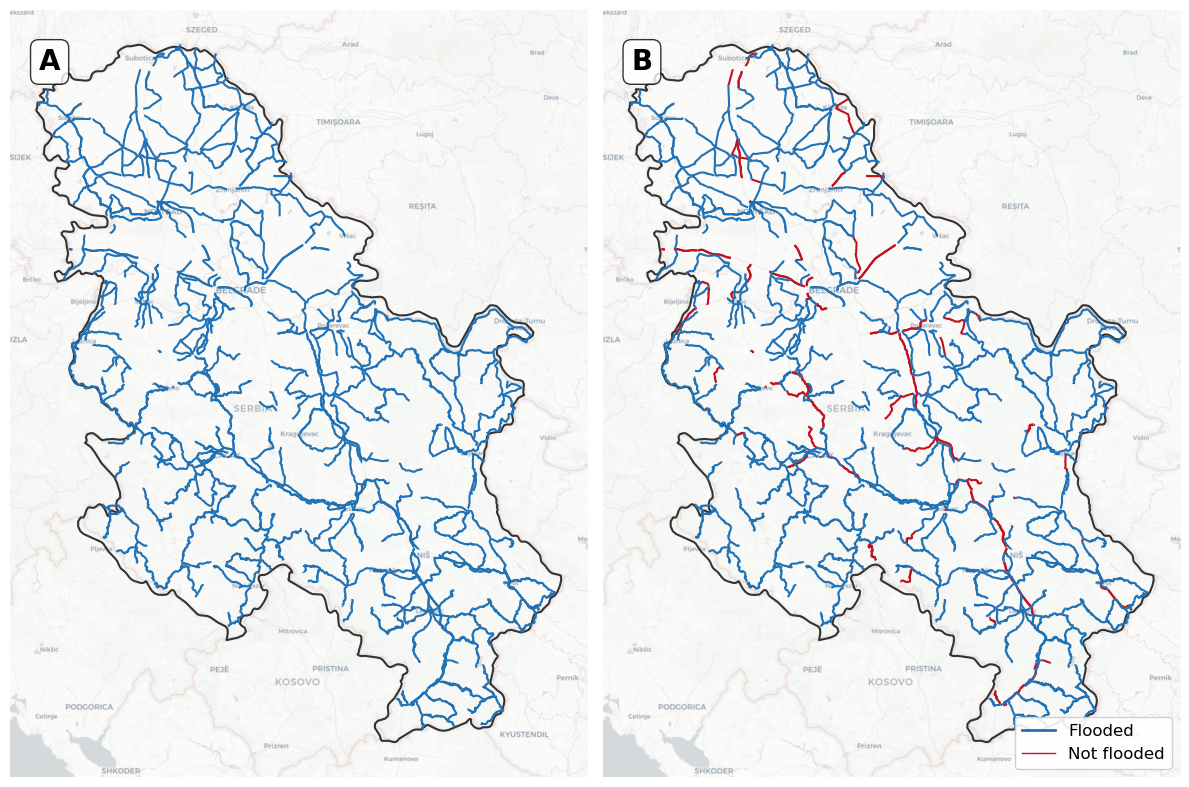

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8), facecolor='white')

serbia_mercator = country_plot.to_crs(3857)

for idx, (label, col) in enumerate([('A', 'max_depth'), ('B', 'corrected_max_depth')]):
    ax = axes[idx]
    
    gdf_mercator = exposed_roads.to_crs(3857)
    
    # Country outline
    serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333', 
                         linewidth=1.5, zorder=1)
    
    # Non-flooded roads (grey)
    not_flooded = gdf_mercator[gdf_mercator[col] == 0]
    if not not_flooded.empty:
        not_flooded.plot(ax=ax, color='#c1121f', linewidth=1.5, zorder=2)
    
    # Flooded roads (blue)
    flooded = gdf_mercator[gdf_mercator[col] > 0]
    if not flooded.empty:
        flooded.plot(ax=ax, color='#2171b5', linewidth=1.5, zorder=3)
    
    # Basemap
    cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, 
                  attribution=False)
    
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Panel label
    ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=20, 
            fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#2171b5', lw=2, label='Flooded'),
    Line2D([0], [0], color='#c1121f', lw=1, label='Not flooded'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=12,
               frameon=True, fancybox=True, framealpha=0.9,
               facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(figure_path / 'flood_exposure_correction.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
corrected_roads = exposed_roads.loc[exposed_roads.corrected_max_depth > 0]

In [21]:
gdf_vhl_flooded = gdf_results.merge(corrected_roads.loc[corrected_roads.exposed][['coverage','values','corrected_max_depth']],left_index=True,right_index=True)

In [22]:
gdf_vhl_flooded

,from_id,to_id,objectid,oznaka_deo,smer_gdf1,kategorija,oznaka_put,oznaka_poc,naziv_poce,oznaka_zav,...,distance_disruption,time_disruption,vhl,phl,thl,pkl,tkl,coverage,values,corrected_max_depth
29,45,20,19.0,A1026,L,IA,A1,A113,petlja Novi Sad istok,A112,...,0.000003,0.000002,34.643231,68.427635,80.674336,6404.484871,7550.714950,"[68.64250529359433, 68.68144568218882, 68.7268...","[4.563000202178955, 4.563000202178955, 3.66300...",1.862
42,40,62,29.0,A1027,D,IA,A1,A113,petlja Novi Sad istok,A114,...,0.000002,0.000002,12.902604,25.485345,30.046534,2364.869264,2788.117088,"[49.01534327804492, 46.488329801416725, 26.650...","[1.7630000114440918, 2.4630000591278076, 2.763...",1.158
43,62,63,29.0,A1027,D,IA,A1,A113,petlja Novi Sad istok,A114,...,0.000003,0.000002,12.902604,25.485345,30.046534,2364.869264,2788.117088,"[32.23266376625504, 78.2288324737096, 1.748557...","[4.059000015258789, 3.8589999675750732, 4.0590...",0.755
46,66,67,32.0,A1028,L,IA,A1,A114,petlja Novi Sad jug,A113,...,0.000129,0.000111,816.728489,1613.209773,1901.930819,150860.305926,177860.232372,"[44.61249330789021, 42.47869043586909, 34.8205...","[3.8589999675750732, 3.757999897003174, 4.3590...",0.554
47,67,45,32.0,A1028,L,IA,A1,A114,petlja Novi Sad jug,A113,...,0.000202,0.000173,2110.052821,4167.796125,4913.719236,169581.293354,199931.771692,"[37.710607132996316, 77.0000074900997, 32.6276...","[1.7630000114440918, 2.4630000591278076, 3.163...",1.158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3199,0,0,1217.0,15901,,IIA,159,M705,petlja Kostoloac,15901,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,[69.7943791674151],[1.4229999780654907],0.603
3201,0,0,1292.0,17201,,IIA,172,17101,Bajina Bašta (Perućac),17201,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"[20.050132744426147, 6.630929392816439, 69.866...","[1.9579999446868896, 7.118000030517578, 7.1110...",19.058
3204,0,0,1398.0,19602,,IIA,196,2130,Arilje,19503,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"[43.45029399793323, 87.27022708531138, 88.1485...","[3.51200008392334, 0.25699999928474426, 3.1600...",11.701
3207,0,0,1514.0,22601,,IIA,226,21604,Prokuplje (Žitorađa),22601,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"[62.825116788868876, 66.05985283448938]","[0.9300000071525574, 4.074999809265137]",3.255


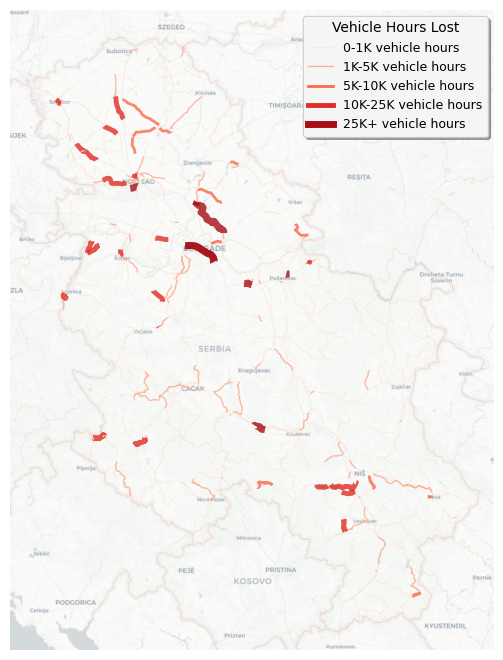

In [23]:
# Define bins based on vehicle hours lost distribution - heavily skewed toward 0
bins = [0, 1000, 5000, 10000, 25000, np.inf]
labels = ['0-1K', '1K-5K', '5K-10K', '10K-25K', '25K+']

# Create binned column
gdf_vhl_flooded['vhl_class'] = pd.cut(
    gdf_vhl_flooded['vhl'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)

# Define line widths for each class (higher VHL = thicker lines)
linewidth_map = {
    '0-1K': 0.5,
    '1K-5K': 1.0,
    '5K-10K': 2.0,
    '10K-25K': 3.5,
    '25K+': 5.0
}

# Create a linewidth column
gdf_vhl_flooded['linewidth'] = gdf_vhl_flooded['vhl_class'].map(linewidth_map)

# Create figure with high DPI for crisp visuals
fig, ax = plt.subplots(1, 1, figsize=(20, 8), facecolor='white')

# Plot each class separately with both width and color variation
# Using red-orange color progression for impact severity
colors = ['#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15']

for i, (class_name, width) in enumerate(linewidth_map.items()):
    subset = gdf_vhl_flooded[gdf_vhl_flooded['vhl_class'] == class_name]
    if not subset.empty:
        subset.to_crs(3857).plot(
            ax=ax,
            color=colors[i],
            linewidth=width,
            alpha=0.8,
            label=class_name
        )

# Add basemap with optimal styling
cx.add_basemap(ax=ax,
    source=cx.providers.CartoDB.Positron,
                attribution=False)


# Enhance the plot styling
ax.set_aspect('equal')
ax.axis('off')

# Create custom legend with line samples that show both width and color
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors[i], lw=width, label=f'{class_name} vehicle hours')
                  for i, (class_name, width) in enumerate(linewidth_map.items())]

legend = ax.legend(handles=legend_elements, 
                  title='Vehicle Hours Lost', 
                  loc='upper right',
                  fontsize=9,
                  title_fontsize=10,
                  frameon=True,
                  fancybox=True,
                  shadow=True,
                  framealpha=0.9,
                  facecolor='white',
                  edgecolor='#cccccc')

# Enhance overall plot appearance
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.08, left=0.02, right=0.94)
plt.savefig(figure_path / 'vehicle_hours_lost_map_flooded.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
snow_drift = gpd.read_file(data_path / "snezni_nanosi_studije.shp")

c:\Users\yma794\AppData\Local\miniforge3\envs\criticality_env\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured LineString' is converted to 'LineString'
  return ogr_read(


In [25]:
gdf_vhl_snowdrift = gdf_results[['from_id', 'to_id', 'objectid', 'oznaka_deo', 'smer_gdf1', 'kategorija',
       'oznaka_put', 'oznaka_poc', 'naziv_poce', 'oznaka_zav', 'naziv_zavr',
       'duzina_deo', 'pocetna_st', 'zavrsna_st', 'stanje', 'geometry', 'id',
       'passenger_cars', 'buses', 'light_trucks', 'medium_trucks',
       'heavy_trucks', 'articulated_vehicles', 'total_aadt', 'road_length', 'speed', 'fft','edge_no', 'vhl','phl','thl','pkl','tkl']].sjoin(snow_drift)

In [26]:
landslides = gpd.read_file(data_path / "Nestabilne_pojave.shp")
#filter to only include actual landslides and not rockfall, etc
landslides = landslides[landslides['tip'] == 'Klizište']

landslides.geometry = landslides.geometry.buffer(10)

In [27]:
gdf_vhl_landslides = gdf_results[['from_id', 'to_id', 'objectid', 'oznaka_deo', 'smer_gdf1', 'kategorija',
       'oznaka_put', 'oznaka_poc', 'naziv_poce', 'oznaka_zav', 'naziv_zavr',
       'duzina_deo', 'pocetna_st', 'zavrsna_st', 'stanje', 'geometry', 'id',
       'passenger_cars', 'buses', 'light_trucks', 'medium_trucks',
       'heavy_trucks', 'articulated_vehicles', 'total_aadt', 'road_length', 'speed', 'fft','edge_no','vhl','phl','thl','pkl','tkl']].sjoin(landslides)

In [28]:
with rasterio.open(data_path / "wildfire risk" / "stepen ugrozenosti od pozara Srbijasume.tif") as src:
    wildfire = src.read()        # numpy array, shape: (bands, rows, cols)
    transform = src.transform    # affine transform (pixel → coordinates)
    crs = src.crs                # coordinate reference system
    profile = src.profile        # full metadata dict

In [29]:
print(f"Wildfire CRS: {crs}")
print(f"Roads CRS: {gdf_results.crs}")

Wildfire CRS: EPSG:32634
Roads CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "MGI 1901 / Balkans zone 7", "base_crs": {"type": "GeographicCRS", "name": "MGI 1901", "datum": {"type": "GeodeticReferenceFrame", "name": "MGI 1901", "ellipsoid": {"name": "Bessel 1841", "semi_major_axis": 6377397.155, "inverse_flattening": 299.1528128}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 3906}}, "conversion": {"name": "Balkans zone 7", "method": {"name": "Transverse Mercator", "id": {"authority": "EPSG", "code": 9807}}, "parameters": [{"name": "Latitude of natural origin", "value": 0, "unit": "degree", "id": {"authority": "EPSG", "code": 8801}}, {"name": "Longitude of natural origin", "value": 21, "unit": "d

In [30]:
# Read wildfire raster as xarray dataset (same pattern as flood)
wildfire_path = data_path / "wildfire risk" / "stepen ugrozenosti od pozara Srbijasume.tif"
wildfire_map = xr.open_dataset(wildfire_path, engine="rasterio")

# Make binary: set all valid values to 1
wildfire_binary = wildfire_map.where(wildfire_map > 0, other=np.nan)
wildfire_binary = wildfire_binary.where(wildfire_binary.isnull(), other=1.0)

country_bounds = world.loc[world.SOV_A3 == 'SRB'].to_crs(epsg=32634).bounds

# Clip to Serbia
wildfire_country = wildfire_binary.rio.clip_box(
    minx=country_bounds.minx.values[0],
    miny=country_bounds.miny.values[0],
    maxx=country_bounds.maxx.values[0],
    maxy=country_bounds.maxy.values[0]
).load()

# Run exposure
gdf_results_32634 = gdf_results.to_crs(epsg=32634)

exposed_wildfire = DamageScanner(
    wildfire_country, 
    gdf_results_32634, 
    curves=pd.DataFrame(), 
    maxdam=pd.DataFrame()
).exposure(asset_type='roads', disable_progress=False, return_full=False)

Overlay raster with vector: 100%|██████████| 49/49 [00:27<00:00,  1.81it/s]


In [31]:
exposed_wildfire['wildfire_coverage_m'] = exposed_wildfire['coverage'].apply(lambda c: sum(c))
exposed_wildfire['wildfire_coverage_pct'] = (exposed_wildfire['wildfire_coverage_m'] / (exposed_wildfire['road_length'] * 1000)) * 100

In [32]:
exposed_wildfire['wildfire_susc'] = 1
gdf_vhl_wildfire = exposed_wildfire.to_crs(gdf_results.crs).copy()

In [33]:
# Read pavement temperature raster and extract max temperature per road
temp_path = intermediate_results_path / "future_pavement_temperatures.tif"
from rasterstats import zonal_stats

# Reproject roads to 4326 to match the raster (easier than reprojecting the raster)
gdf_results_4326 = gdf_results.to_crs("EPSG:4326")

stats = zonal_stats(
    gdf_results_4326,
    str(temp_path),
    stats=["max"],
    all_touched=True,       # include pixels touched by the road line
    nodata=np.nan
)

exposed_heat = gdf_results_4326.copy()
exposed_heat['max_pavement_temp'] = [s['max'] for s in stats]

gdf_vhl_heat = exposed_heat.to_crs(gdf_results.crs).copy()

In [34]:
# pick an aggregation rule for duplicates; here we use 'max' as an example
s_depth    = gdf_vhl_flooded['corrected_max_depth'].groupby(level=0).max()
s_snow     = gdf_vhl_snowdrift['dužina_sn'].groupby(level=0).max()
s_date     = gdf_vhl_landslides['datum_evid'].groupby(level=0).max()
s_wildfire = gdf_vhl_wildfire['wildfire_susc'].groupby(level=0).max()
s_heat     = gdf_vhl_heat['max_pavement_temp'].groupby(level=0).max()

# align everything to the base index
gdf_hazards = pd.concat([gdf_results, s_depth.rename('max_depth'),
                         s_snow.rename('dužina_sn'),
                         s_date.rename('datum_evid'),
                         s_wildfire,
                         s_heat], axis=1)

# convert date to string dd/mm/yyyy (NaT -> NaN -> optional empty string)
gdf_hazards['datum_evid'] = gdf_hazards['datum_evid'].dt.strftime('%d/%m/%Y')


In [35]:
keep_attrs = ['oznaka_deo', 'smer_gdf1', 'kategorija',
       'oznaka_put', 'oznaka_poc', 'naziv_poce', 'oznaka_zav', 'naziv_zavr',
       'duzina_deo', 'pocetna_st', 'zavrsna_st', 'stanje', 'geometry',
       'passenger_cars', 'buses', 'light_trucks', 'medium_trucks',
       'heavy_trucks', 'articulated_vehicles', 'total_aadt', 'road_length', 'average_time_disruption','vhl','phl','thl','pkl','tkl','max_depth', 'dužina_sn', 'datum_evid','wildfire_susc', 'max_pavement_temp']  # ← added
gdf_hazards = gdf_hazards[keep_attrs]
gdf_hazards = gdf_hazards.loc[gdf_hazards[['max_depth', 'dužina_sn', 'datum_evid', 'wildfire_susc', 'max_pavement_temp']].any(axis=1)] 
gdf_hazards = gdf_hazards.loc[gdf_hazards['vhl'].notna()]

In [36]:
mask = (
    (gdf_hazards['max_depth'].fillna(0) > 0) &
    (gdf_hazards['dužina_sn'].fillna(0) > 0) &
    (gdf_hazards['datum_evid'].notna()) &
    (gdf_hazards['wildfire_susc'].fillna(0) > 0) &
    (gdf_hazards['max_pavement_temp'].fillna(0) > 0)) 

affected_all = gdf_hazards.loc[mask]

In [37]:
affected_all

,oznaka_deo,smer_gdf1,kategorija,oznaka_put,oznaka_poc,naziv_poce,oznaka_zav,naziv_zavr,duzina_deo,pocetna_st,...,vhl,phl,thl,pkl,tkl,max_depth,dužina_sn,datum_evid,wildfire_susc,max_pavement_temp
634,02135,O,IB,21,2133,Ivanjica,2134,Sjenica,61.336,249.951,...,114.781911,219.449842,62.271539,20686.523091,5870.050363,20.297001,6.000,03/08/2015,1.0,58.760433
661,02234,O,IB,22,2233,Novi Pazar (Brđani),2234,Ribariće,24.390,257.678,...,495.984331,1035.424617,190.995694,98711.792781,18208.498285,2.877000,5.000,06/12/2022,1.0,59.744289
698,02334,O,IB,23,2332,Pakovraće (veza sa A2),2316,Kratovska Stena,17.745,97.799,...,1717.459844,3509.663166,2188.601489,326367.516417,203520.508535,22.582000,10.201,16/06/2014,1.0,55.971981
847,03510,O,IB,35,3510,Salaš,3511,Rgotina,19.485,87.256,...,94.938721,182.095579,103.462454,16957.023770,9634.584759,2.264000,3.000,21/04/2015,1.0,57.781715
888,03904,O,IB,39,3904,Babušnica,3905,Bonjince,17.253,24.028,...,1.109269,2.063581,0.562288,192.036555,52.326444,9.057000,10.100,06/09/2023,1.0,56.115597
1186,16106,O,IIA,161,14719,Petrovac na Mlavi (Malo Laole),16104,Krepoljin,23.410,34.840,...,316.084596,673.617722,87.563976,63577.796046,8264.516231,12.727000,5.750,18/07/2018,1.0,57.408504
1190,17002,O,IIA,170,17001,Sedlari,2803,Rogačica (Debelo brdo),58.127,2.445,...,283.498087,584.928281,57.446788,54896.747265,5391.501711,1.909000,13.000,18/07/2014,1.0,56.084618
1282,22603,O,IIA,226,22503,Dragovac,3912,Leskovac (Gornje Stopanje),20.200,42.640,...,610.640774,1265.303473,98.689748,117082.655222,9132.084123,2.633000,3.756,18/05/2023,1.0,63.907345
1284,23102,O,IIA,231,23101,Sastav Reka,23102,Crna Trava,14.643,14.374,...,23.959363,53.199027,6.488169,4676.541917,570.352445,12.527000,5.289,03/02/2011,1.0,55.285152
1596,14114,O,IIA,141,14111,Pecka,2802,Ljubovija,22.899,97.778,...,104.384800,215.259480,59.897370,19965.149588,5555.434545,5.231000,2.500,20/12/2014,1.0,55.682907


In [38]:
# Normalize mixed-type object columns before saving to parquet
for col in gdf_hazards.select_dtypes(include="object").columns:
    if col == gdf_hazards.geometry.name:
        continue
    # If the column contains any non-string values, cast everything to str
    # (or swap to .fillna(0).astype(int/float) if the column is meant to be numeric)
    has_non_string = gdf_hazards[col].dropna().apply(lambda x: not isinstance(x, str)).any()
    if has_non_string:
        print(f"  Mixed types in '{col}' (dtype=object) — casting to string")
        gdf_hazards[col] = gdf_hazards[col].astype(str)

In [39]:
### save outputs
gdf_hazards.to_parquet(intermediate_results_path / "main_network_hazard_exposure.parquet")

### Map of main network impacts

C:\Users\yma794\AppData\Local\Temp\ipykernel_6220\3182071370.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


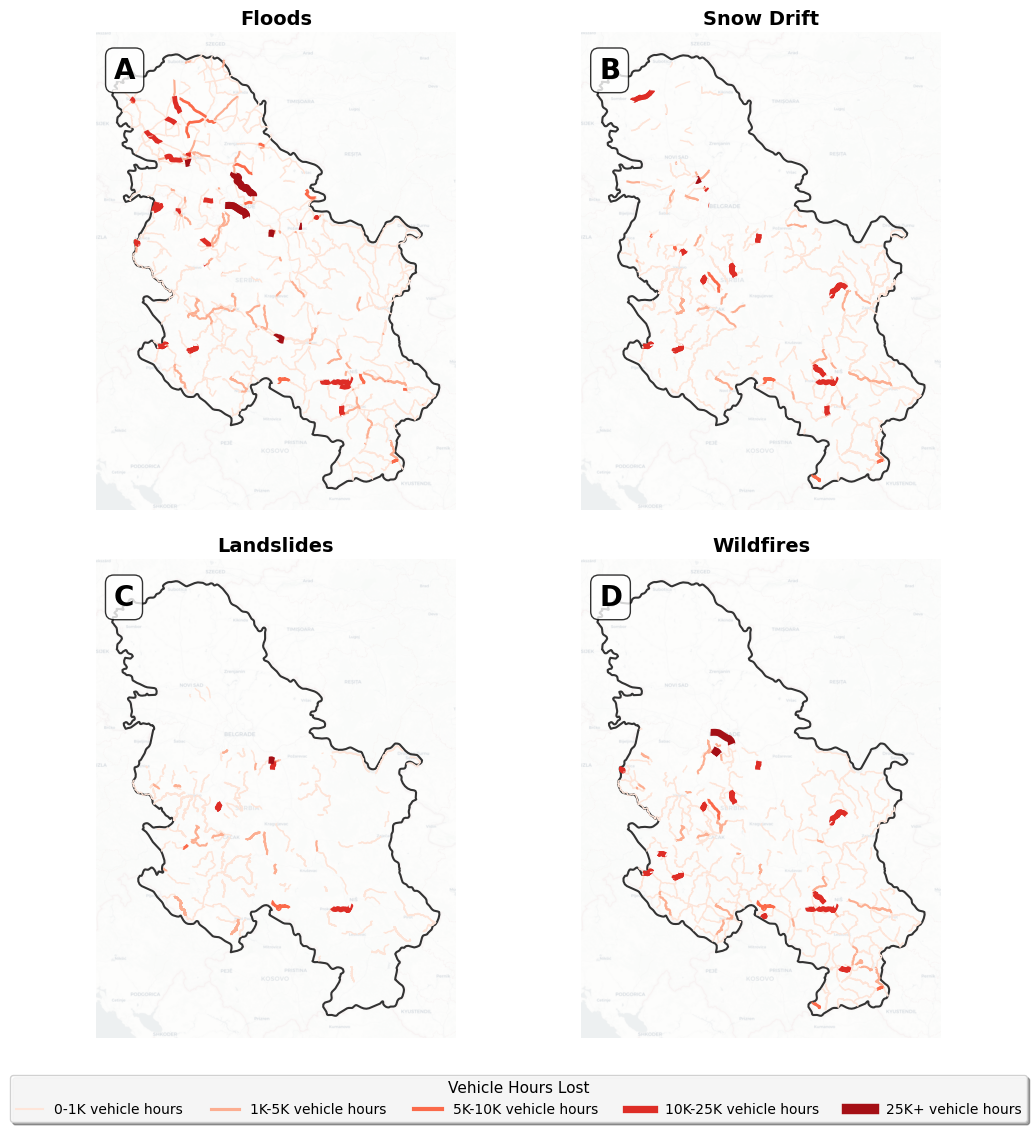

In [40]:
# Define bins and styling (shared across all four)
bins = [0, 1000, 5000, 10000, 25000, np.inf]
labels = ['0-1K', '1K-5K', '5K-10K', '10K-25K', '25K+']
colors = ['#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15']
linewidth_map = {'0-1K': 1, '1K-5K': 1.5, '5K-10K': 2.0, '10K-25K': 3.5, '25K+': 5.0}

# Prepare all four datasets
datasets = {
    'A': ('Floods', gdf_vhl_flooded),
    'B': ('Snow Drift', gdf_vhl_snowdrift),
    'C': ('Landslides', gdf_vhl_landslides),
    'D': ('Wildfires', gdf_vhl_wildfire)
}

# Bin all datasets
for letter, (title, gdf) in datasets.items():
    gdf['vhl_class'] = pd.cut(gdf['vhl'], bins=bins, labels=labels, include_lowest=True)

fig = plt.figure(figsize=(12, 14), facecolor='white')
gs = fig.add_gridspec(3, 4, height_ratios=[1, 1, 0.05], hspace=0.15)
ax_A      = fig.add_subplot(gs[0, 0:2])
ax_B      = fig.add_subplot(gs[0, 2:4])
ax_C      = fig.add_subplot(gs[1, 0:2])
ax_D      = fig.add_subplot(gs[1, 2:4])
ax_legend = fig.add_subplot(gs[2, :])

axes_map = {'A': ax_A, 'B': ax_B, 'C': ax_C, 'D': ax_D}

# Convert country boundary once
serbia_mercator = country_plot.to_crs(3857)

# Plot the four hazard maps
for letter, (title, gdf) in datasets.items():
    ax = axes_map[letter]
    gdf_mercator = gdf.to_crs(3857)

    serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333',
                         linewidth=1.5, zorder=1)

    for i, (class_name, width) in enumerate(linewidth_map.items()):
        subset = gdf_mercator[gdf_mercator['vhl_class'] == class_name]
        if not subset.empty:
            subset.plot(ax=ax, color=colors[i], linewidth=width, zorder=2)

    cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron,
                   alpha=0.4, attribution=False)

    ax.set_aspect('equal')
    ax.axis('off')

    ax.text(0.05, 0.95, f'{letter}', transform=ax.transAxes, fontsize=20,
            fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=6)

# Legend panel
ax_legend.axis('off')

legend_elements = [
    Line2D([0], [0], color=colors[i], lw=width * 1.5, label=f'{class_name} vehicle hours')
    for i, (class_name, width) in enumerate(linewidth_map.items())
]

ax_legend.legend(handles=legend_elements,
                 title='Vehicle Hours Lost',
                 loc='center',
                 fontsize=10,
                 title_fontsize=11,
                 frameon=True,
                 fancybox=True,
                 shadow=True,
                 framealpha=0.9,
                 facecolor='white',
                 ncols=5,
                 edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(figure_path / 'vhl_hazards_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

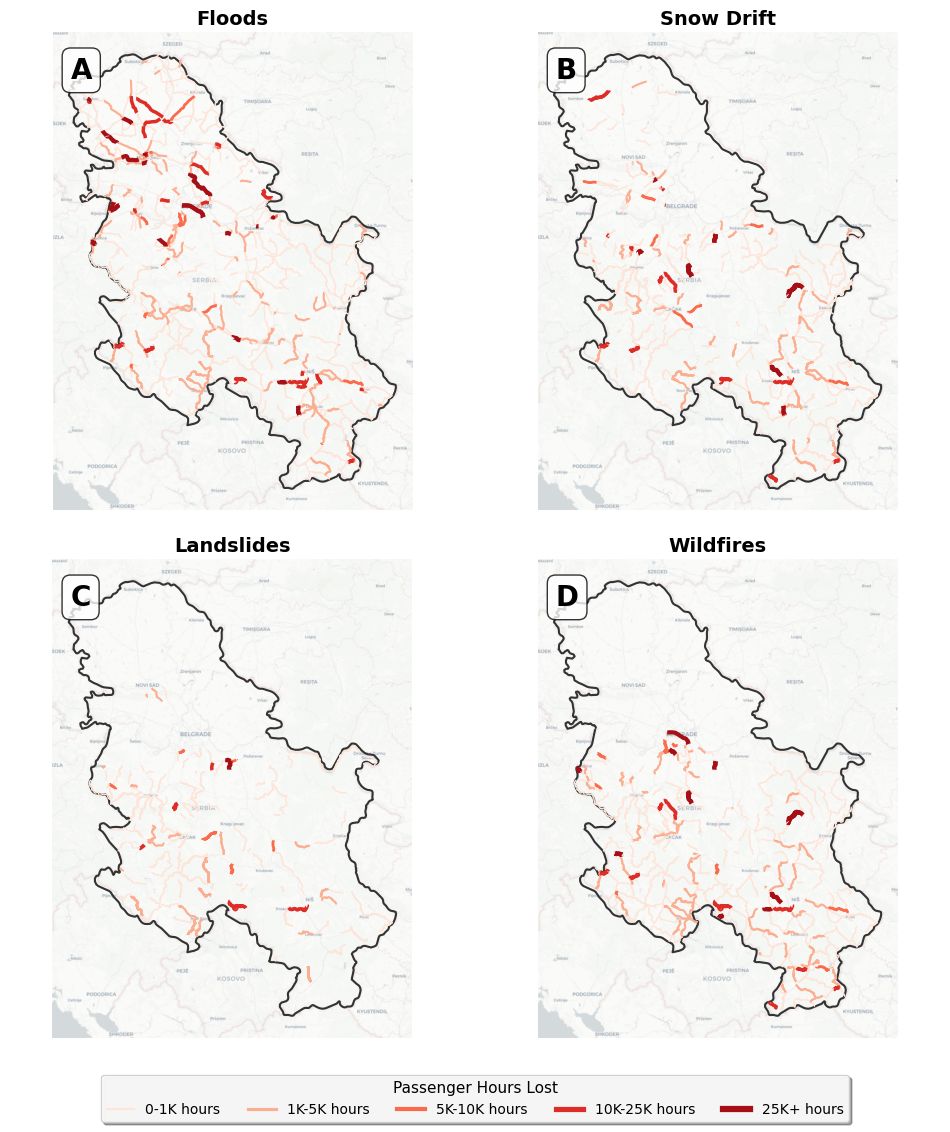

In [41]:
# ============================================================
# FIGURE: PASSENGER HOURS LOST BY HAZARD TYPE
# ============================================================
# Define bins and styling for PHL
bins_phl = [0, 1000, 5000, 10000, 25000, np.inf]
labels_phl = ['0-1K', '1K-5K', '5K-10K', '10K-25K', '25K+']
colors = ['#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15']
linewidth_map = {'0-1K': 1, '1K-5K': 1.5, '5K-10K': 2.0, '10K-25K': 2.5, '25K+': 3.0}

datasets_phl = {
    'A': ('Floods', gdf_vhl_flooded),
    'B': ('Snow Drift', gdf_vhl_snowdrift),
    'C': ('Landslides', gdf_vhl_landslides),
    'D': ('Wildfires', gdf_vhl_wildfire)
}

for letter, (title, gdf) in datasets_phl.items():
    gdf['phl_class'] = pd.cut(gdf['phl'], bins=bins_phl, labels=labels_phl, include_lowest=True)

fig = plt.figure(figsize=(12, 14), facecolor='white')
gs = fig.add_gridspec(3, 4, height_ratios=[1, 1, 0.05], hspace=0.15)
ax_A      = fig.add_subplot(gs[0, 0:2])
ax_B      = fig.add_subplot(gs[0, 2:4])
ax_C      = fig.add_subplot(gs[1, 0:2])
ax_D      = fig.add_subplot(gs[1, 2:4])
ax_legend = fig.add_subplot(gs[2, :])

axes_map = {'A': ax_A, 'B': ax_B, 'C': ax_C, 'D': ax_D}

serbia_mercator = country_plot.to_crs(3857)

for letter, (title, gdf) in datasets_phl.items():
    ax = axes_map[letter]
    gdf_mercator = gdf.to_crs(3857)
    
    serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333', 
                         linewidth=1.5, zorder=1)
    
    for i, (class_name, width) in enumerate(linewidth_map.items()):
        subset = gdf_mercator[gdf_mercator['phl_class'] == class_name]
        if not subset.empty:
            subset.plot(ax=ax, color=colors[i], linewidth=width, zorder=2)
    
    cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, 
                   attribution=False)
    
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=6)
    ax.text(0.05, 0.95, f'{letter}', transform=ax.transAxes, fontsize=20, 
            fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

ax_legend.axis('off')
legend_elements = [
    Line2D([0], [0], color=colors[i], lw=width * 1.5, label=f'{class_name} hours')
    for i, (class_name, width) in enumerate(linewidth_map.items())
]
ax_legend.legend(handles=legend_elements, 
                 title='Passenger Hours Lost',
                 loc='center',
                 ncols=5,
                 fontsize=10,
                 title_fontsize=11,
                 frameon=True,
                 fancybox=True,
                 shadow=True,
                 framealpha=0.9,
                 facecolor='white',
                 edgecolor='#cccccc')

plt.savefig(figure_path / 'phl_hazards_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

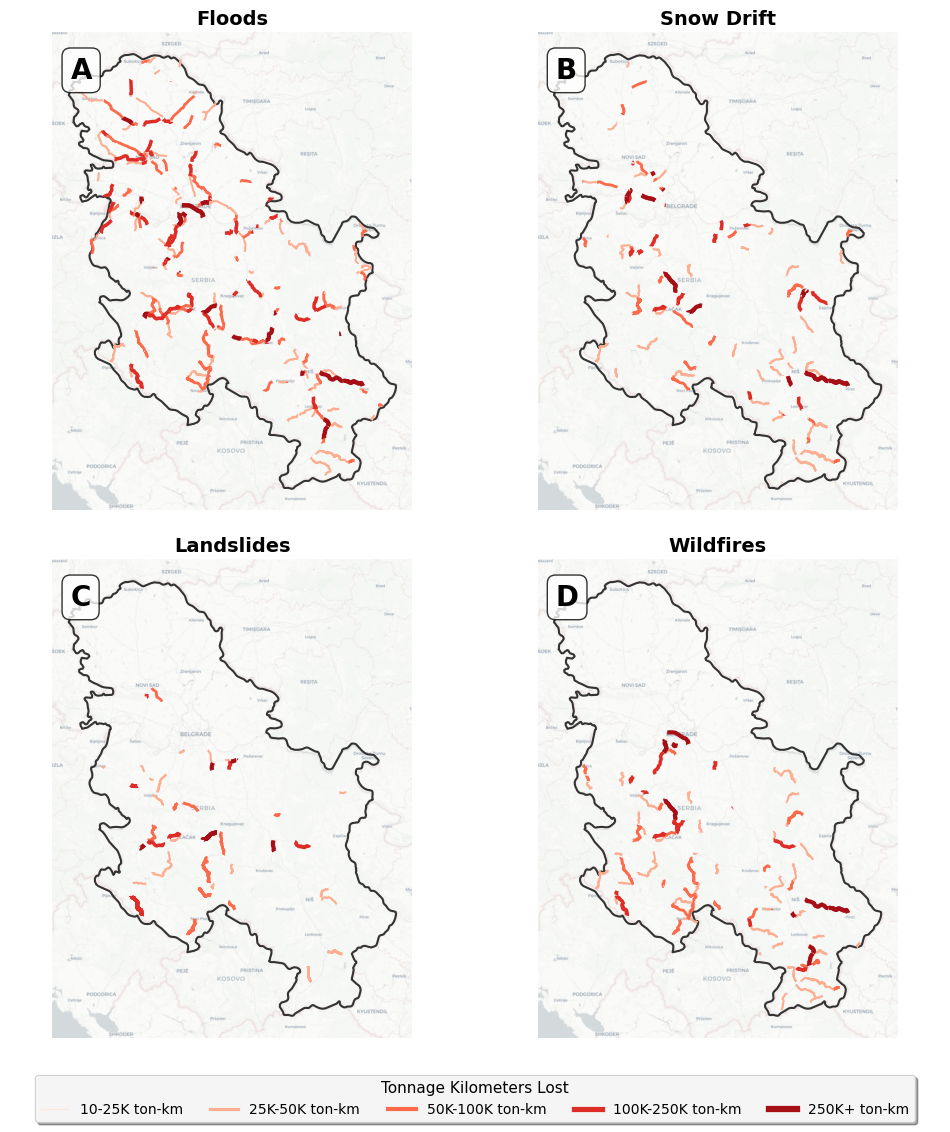

In [42]:
# ============================================================
# FIGURE 3: TONNAGE KILOMETERS LOST BY HAZARD TYPE
# ============================================================
# Define bins and styling for TKL

bins_tkl = [10000, 25000, 50000, 100000, 250000, np.inf]
labels_tkl = ['10K-25K', '25K-50K', '50K-100K', '100K-250K', '250K+']
linewidth_map_tkl = {
    '10-25K': 0.5, '25K-50K': 1.5, '50K-100K': 2.0, 
    '100K-250K': 2.5, '250K+': 3.0
}

datasets_tkl = {
    'A': ('Floods', gdf_vhl_flooded),
    'B': ('Snow Drift', gdf_vhl_snowdrift),
    'C': ('Landslides', gdf_vhl_landslides),
    'D': ('Wildfires', gdf_vhl_wildfire)
}

for letter, (title, gdf) in datasets_tkl.items():
    gdf['tkl_class'] = pd.cut(gdf['tkl'], bins=bins_tkl, labels=labels_tkl, include_lowest=True)

fig = plt.figure(figsize=(12, 14), facecolor='white')
gs = fig.add_gridspec(3, 4, height_ratios=[1, 1, 0.05], hspace=0.15)
ax_A      = fig.add_subplot(gs[0, 0:2])
ax_B      = fig.add_subplot(gs[0, 2:4])
ax_C      = fig.add_subplot(gs[1, 0:2])
ax_D      = fig.add_subplot(gs[1, 2:4])
ax_legend = fig.add_subplot(gs[2, :])

axes_map = {'A': ax_A, 'B': ax_B, 'C': ax_C, 'D': ax_D}

serbia_mercator = country_plot.to_crs(3857)

for letter, (title, gdf) in datasets_tkl.items():
    ax = axes_map[letter]
    gdf_mercator = gdf.to_crs(3857)
    serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333',
                         linewidth=1.5, zorder=1)
    for i, (class_name, width) in enumerate(linewidth_map_tkl.items()):
        subset = gdf_mercator[gdf_mercator['tkl_class'] == class_name]
        if not subset.empty:
            subset.plot(ax=ax, color=colors[i], linewidth=width, zorder=2)
    cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron,
                  attribution=False)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=6)
    ax.text(0.05, 0.95, f'{letter}', transform=ax.transAxes, fontsize=20,
            fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

ax_legend.axis('off')
legend_elements = [
    Line2D([0], [0], color=colors[i], lw=width * 1.5, label=f'{class_name} ton-km')
    for i, (class_name, width) in enumerate(linewidth_map_tkl.items())
]

ax_legend.legend(handles=legend_elements,
                 title='Tonnage Kilometers Lost',
                 loc='center',
                 ncols=5,
                 fontsize=10,
                 title_fontsize=11,
                 frameon=True,
                 fancybox=True,
                 shadow=True,
                 framealpha=0.9,
                 facecolor='white',
                 edgecolor='#cccccc')

plt.savefig(figure_path / 'tkl_hazards_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
# ============================================================
# HAZARD EXPOSURE ANALYSIS - UPDATED FOR PHL, THL, PKL, TKL
# ============================================================

print("=" * 70)
print("BASELINE RESULTS - ALL METRICS")
print("=" * 70)

print(f"\nTotal road segments analyzed: {len(gdf_results):,}")

metrics_summary = gdf_results[['phl', 'thl', 'pkl', 'tkl']].describe()
print("\nAll Metrics Summary:")
print(metrics_summary.round(2))

print(f"\nTotals across network:")
print(f"  Total PHL: {gdf_results['phl'].sum():,.0f} passenger hours")
print(f"  Total THL: {gdf_results['thl'].sum():,.0f} ton hours")
print(f"  Total PKL: {gdf_results['pkl'].sum():,.0f} passenger km")
print(f"  Total TKL: {gdf_results['tkl'].sum():,.0f} ton km")

gdf_vhl_snowdrift  = gdf_vhl_snowdrift.rename(columns = {'oznaka_deo_left' : 'oznaka_deo'})
gdf_vhl_landslides = gdf_vhl_landslides.rename(columns = {'oznaka_deo_left' : 'oznaka_deo'})

# ============================================================
# HAZARD-SPECIFIC ANALYSIS
# ============================================================

hazard_datasets = {
    'Floods': gdf_vhl_flooded,
    'Snow Drift': gdf_vhl_snowdrift,
    'Landslides': gdf_vhl_landslides,
    'Wildfires': gdf_vhl_wildfire
}

# Define bins for each metric
bins_phl = [0, 1000, 5000, 10000, 25000, np.inf]
labels_phl = ['0-1K', '1K-5K', '5K-10K', '10K-25K', '25K+']

bins_thl = [0, 500, 2500, 5000, 10000, np.inf]
labels_thl = ['0-500', '500-2.5K', '2.5K-5K', '5K-10K', '10K+']

bins_pkl = [0, 10000, 50000, 100000, 250000, np.inf]
labels_pkl = ['0-10K', '10K-50K', '50K-100K', '100K-250K', '250K+']

bins_tkl = [0, 10000, 50000, 100000, 250000, np.inf]
labels_tkl = ['0-10K', '10K-50K', '50K-100K', '100K-250K', '250K+']


# ============================================================
# PASSENGER HOURS LOST (PHL)
# ============================================================

print("\n" + "=" * 70)
print("PASSENGER HOURS LOST (PHL) BY HAZARD")
print("=" * 70)

phl_summary = []

for hazard_name, gdf in hazard_datasets.items():
    print(f"\n{'─' * 50}")
    print(f"{hazard_name.upper()}")
    print(f"{'─' * 50}")
    
    print(f"Exposed road segments: {len(gdf):,}")
    print(f"\nPHL Statistics:")
    print(gdf['phl'].describe().round(2))
    
    print(f"\nTotal PHL: {gdf['phl'].sum():,.0f} passenger hours")
    print(f"Mean PHL: {gdf['phl'].mean():,.2f} passenger hours")
    print(f"Median PHL: {gdf['phl'].median():,.2f} passenger hours")
    print(f"Max PHL: {gdf['phl'].max():,.2f} passenger hours")
    
    gdf['phl_class'] = pd.cut(gdf['phl'], bins=bins_phl, labels=labels_phl, include_lowest=True)
    print(f"\nSegments by PHL category:")
    phl_counts = gdf['phl_class'].value_counts().sort_index()
    phl_pcts = (gdf['phl_class'].value_counts(normalize=True).sort_index() * 100).round(1)
    for label in labels_phl:
        count = phl_counts.get(label, 0)
        pct = phl_pcts.get(label, 0)
        print(f"  {label}: {count} ({pct}%)")
    
    if 'kategorija' in gdf.columns:
        print(f"\nPHL by road category:")
        road_summary = gdf.groupby('kategorija')['phl'].agg(['count', 'sum', 'mean', 'max']).round(2)
        road_summary.columns = ['Count', 'Total PHL', 'Mean PHL', 'Max PHL']
        print(road_summary.sort_values('Total PHL', ascending=False))
    
    print(f"\nTop 5 most critical segments (PHL):")
    cols = ['oznaka_deo', 'kategorija', 'naziv_poce', 'naziv_zavr', 'total_aadt', 'phl']
    cols = [c for c in cols if c in gdf.columns]
    print(gdf.nlargest(5, 'phl')[cols].to_string())
    
    phl_summary.append({
        'Hazard': hazard_name,
        'Exposed Segments': len(gdf),
        'Total PHL': gdf['phl'].sum(),
        'Mean PHL': gdf['phl'].mean(),
        'Median PHL': gdf['phl'].median(),
        'Max PHL': gdf['phl'].max(),
        'Segments >25K': len(gdf[gdf['phl'] >= 25000]),
        'Segments >10K': len(gdf[gdf['phl'] >= 10000])
    })

print("\n" + "─" * 50)
print("PHL HAZARD COMPARISON SUMMARY")
print("─" * 50)
phl_summary_df = pd.DataFrame(phl_summary)
print(phl_summary_df.to_string(index=False))


# ============================================================
# TONNAGE KILOMETERS LOST (TKL)
# ============================================================

print("\n" + "=" * 70)
print("TONNAGE KILOMETERS LOST (TKL) BY HAZARD")
print("=" * 70)

tkl_summary = []

for hazard_name, gdf in hazard_datasets.items():
    print(f"\n{'─' * 50}")
    print(f"{hazard_name.upper()}")
    print(f"{'─' * 50}")
    
    print(f"Exposed road segments: {len(gdf):,}")
    print(f"\nTKL Statistics:")
    print(gdf['tkl'].describe().round(2))
    
    print(f"\nTotal TKL: {gdf['tkl'].sum():,.0f} ton-km")
    print(f"Mean TKL: {gdf['tkl'].mean():,.2f} ton-km")
    print(f"Median TKL: {gdf['tkl'].median():,.2f} ton-km")
    print(f"Max TKL: {gdf['tkl'].max():,.2f} ton-km")
    
    gdf['tkl_class'] = pd.cut(gdf['tkl'], bins=bins_tkl, labels=labels_tkl, include_lowest=True)
    print(f"\nSegments by TKL category:")
    tkl_counts = gdf['tkl_class'].value_counts().sort_index()
    tkl_pcts = (gdf['tkl_class'].value_counts(normalize=True).sort_index() * 100).round(1)
    for label in labels_tkl:
        count = tkl_counts.get(label, 0)
        pct = tkl_pcts.get(label, 0)
        print(f"  {label}: {count} ({pct}%)")
    
    if 'kategorija' in gdf.columns:
        print(f"\nTKL by road category:")
        road_summary = gdf.groupby('kategorija')['tkl'].agg(['count', 'sum', 'mean', 'max']).round(2)
        road_summary.columns = ['Count', 'Total TKL', 'Mean TKL', 'Max TKL']
        print(road_summary.sort_values('Total TKL', ascending=False))
    
    print(f"\nTop 5 most critical segments (TKL):")
    cols = ['oznaka_deo', 'kategorija', 'naziv_poce', 'naziv_zavr', 'total_aadt', 'tkl']
    cols = [c for c in cols if c in gdf.columns]
    print(gdf.nlargest(5, 'tkl')[cols].to_string())
    
    tkl_summary.append({
        'Hazard': hazard_name,
        'Exposed Segments': len(gdf),
        'Total TKL': gdf['tkl'].sum(),
        'Mean TKL': gdf['tkl'].mean(),
        'Median TKL': gdf['tkl'].median(),
        'Max TKL': gdf['tkl'].max(),
        'Segments >250K': len(gdf[gdf['tkl'] >= 250000]),
        'Segments >100K': len(gdf[gdf['tkl'] >= 100000])
    })

print("\n" + "─" * 50)
print("TKL HAZARD COMPARISON SUMMARY")
print("─" * 50)
tkl_summary_df = pd.DataFrame(tkl_summary)
print(tkl_summary_df.to_string(index=False))


# ============================================================
# ADDITIONAL METRICS: THL and PKL
# ============================================================

print("\n" + "=" * 70)
print("TONNAGE HOURS LOST (THL) BY HAZARD")
print("=" * 70)

thl_summary = []
for hazard_name, gdf in hazard_datasets.items():
    thl_summary.append({
        'Hazard': hazard_name,
        'Exposed Segments': len(gdf),
        'Total THL': gdf['thl'].sum(),
        'Mean THL': gdf['thl'].mean(),
        'Max THL': gdf['thl'].max(),
        'Segments >10K': len(gdf[gdf['thl'] >= 10000])
    })
thl_summary_df = pd.DataFrame(thl_summary)
print(thl_summary_df.to_string(index=False))


print("\n" + "=" * 70)
print("PASSENGER KILOMETERS LOST (PKL) BY HAZARD")
print("=" * 70)

pkl_summary = []
for hazard_name, gdf in hazard_datasets.items():
    pkl_summary.append({
        'Hazard': hazard_name,
        'Exposed Segments': len(gdf),
        'Total PKL': gdf['pkl'].sum(),
        'Mean PKL': gdf['pkl'].mean(),
        'Max PKL': gdf['pkl'].max(),
        'Segments >250K': len(gdf[gdf['pkl'] >= 250000]),
        'Segments >500K': len(gdf[gdf['pkl'] >= 500000])
    })
pkl_summary_df = pd.DataFrame(pkl_summary)
print(pkl_summary_df.to_string(index=False))


# ============================================================
# OVERLAP ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("OVERLAP ANALYSIS - MULTI-HAZARD EXPOSURE")
print("=" * 70)

id_col = 'oznaka_deo'

flooded_segments = set(gdf_vhl_flooded[id_col].dropna())
snow_segments = set(gdf_vhl_snowdrift[id_col].dropna())
landslide_segments = set(gdf_vhl_landslides[id_col].dropna())
wildfire_segments = set(gdf_vhl_wildfire[id_col].dropna())

print(f"\nTotal unique segments exposed to floods: {len(flooded_segments)}")
print(f"Total unique segments exposed to snow drift: {len(snow_segments)}")
print(f"Total unique segments exposed to landslides: {len(landslide_segments)}")
print(f"Total unique segments exposed to wildfires: {len(wildfire_segments)}")

all_hazards = [flooded_segments, snow_segments, landslide_segments, wildfire_segments]
all_exposed = flooded_segments | snow_segments | landslide_segments | wildfire_segments

print(f"\nTotal unique segments exposed to any hazard: {len(all_exposed)}")

print(f"\nExclusive exposure:")
print(f"  Floods only: {len(flooded_segments - snow_segments - landslide_segments - wildfire_segments)}")
print(f"  Snow drift only: {len(snow_segments - flooded_segments - landslide_segments - wildfire_segments)}")
print(f"  Landslides only: {len(landslide_segments - flooded_segments - snow_segments - wildfire_segments)}")
print(f"  Wildfires only: {len(wildfire_segments - flooded_segments - snow_segments - landslide_segments)}")

print(f"\nDual exposure:")
print(f"  Floods AND snow drift: {len((flooded_segments & snow_segments) - landslide_segments - wildfire_segments)}")
print(f"  Floods AND landslides: {len((flooded_segments & landslide_segments) - snow_segments - wildfire_segments)}")
print(f"  Floods AND wildfires: {len((flooded_segments & wildfire_segments) - snow_segments - landslide_segments)}")
print(f"  Snow drift AND landslides: {len((snow_segments & landslide_segments) - flooded_segments - wildfire_segments)}")
print(f"  Snow drift AND wildfires: {len((snow_segments & wildfire_segments) - flooded_segments - landslide_segments)}")
print(f"  Landslides AND wildfires: {len((landslide_segments & wildfire_segments) - flooded_segments - snow_segments)}")

print(f"\nTriple exposure:")
print(f"  Floods, snow drift AND landslides: {len((flooded_segments & snow_segments & landslide_segments) - wildfire_segments)}")
print(f"  Floods, snow drift AND wildfires: {len((flooded_segments & snow_segments & wildfire_segments) - landslide_segments)}")
print(f"  Floods, landslides AND wildfires: {len((flooded_segments & landslide_segments & wildfire_segments) - snow_segments)}")
print(f"  Snow drift, landslides AND wildfires: {len((snow_segments & landslide_segments & wildfire_segments) - flooded_segments)}")

print(f"\nQuadruple exposure:")
print(f"  ALL four hazards: {len(flooded_segments & snow_segments & landslide_segments & wildfire_segments)}")

# Count segments by number of hazards
from collections import Counter
segment_hazard_count = Counter()
for seg in all_exposed:
    n = sum(1 for h in all_hazards if seg in h)
    segment_hazard_count[n] += 1

print(f"\nSegments by number of hazards:")
for n in sorted(segment_hazard_count.keys()):
    print(f"  {n} hazard(s): {segment_hazard_count[n]} segments")


# ============================================================
# COMPARISON WITH NATIONAL STATISTICS
# ============================================================

print("\n" + "=" * 70)
print("HAZARD EXPOSURE AS % OF NATIONAL DAILY TRANSPORT")
print("=" * 70)

national_pkm_daily = 2069 * 1e6 / 180
national_tkm_daily = 4677 * 1e6 / 180

print(f"\nNational daily averages (road transport, H1 2025):")
print(f"  Passenger-km/day: {national_pkm_daily:,.0f}")
print(f"  Ton-km/day: {national_tkm_daily:,.0f}")

print(f"\nTotal exposed PKL as % of national daily:")
for hazard_name, gdf in hazard_datasets.items():
    total_pkl = gdf['pkl'].sum()
    pct = total_pkl / national_pkm_daily * 100
    print(f"  {hazard_name}: {total_pkl:,.0f} PKL ({pct:.1f}% of national daily)")

print(f"\nTotal exposed TKL as % of national daily:")
for hazard_name, gdf in hazard_datasets.items():
    total_tkl = gdf['tkl'].sum()
    pct = total_tkl / national_tkm_daily * 100
    print(f"  {hazard_name}: {total_tkl:,.0f} TKL ({pct:.1f}% of national daily)")


# ============================================================
# KEY EXAMPLES FOR TEXT
# ============================================================

print("\n" + "=" * 70)
print("KEY EXAMPLES FOR TEXT")
print("=" * 70)

for hazard_name, gdf in hazard_datasets.items():
    print(f"\n{'─' * 50}")
    print(f"{hazard_name.upper()} - TOP CRITICAL SEGMENTS")
    print(f"{'─' * 50}")
    
    print("\nTop 3 by Passenger Hours Lost:")
    cols = ['oznaka_deo', 'kategorija', 'oznaka_put', 'naziv_poce', 'naziv_zavr', 'total_aadt', 'phl', 'pkl']
    cols = [c for c in cols if c in gdf.columns]
    top_phl = gdf.nlargest(3, 'phl')[cols]
    for idx, row in top_phl.iterrows():
        route = f"{row.get('oznaka_put', 'N/A')} ({row.get('kategorija', 'N/A')})"
        section = f"{row.get('naziv_poce', 'N/A')} → {row.get('naziv_zavr', 'N/A')}"
        print(f"  {route}: {section}")
        print(f"    AADT: {row.get('total_aadt', 0):,.0f}, PHL: {row['phl']:,.0f}, PKL: {row.get('pkl', 0):,.0f}")
    
    print("\nTop 3 by Tonnage Kilometers Lost:")
    cols = ['oznaka_deo', 'kategorija', 'oznaka_put', 'naziv_poce', 'naziv_zavr', 'total_aadt', 'thl', 'tkl']
    cols = [c for c in cols if c in gdf.columns]
    top_tkl = gdf.nlargest(3, 'tkl')[cols]
    for idx, row in top_tkl.iterrows():
        route = f"{row.get('oznaka_put', 'N/A')} ({row.get('kategorija', 'N/A')})"
        section = f"{row.get('naziv_poce', 'N/A')} → {row.get('naziv_zavr', 'N/A')}"
        print(f"  {route}: {section}")
        print(f"    AADT: {row.get('total_aadt', 0):,.0f}, THL: {row.get('thl', 0):,.0f}, TKL: {row['tkl']:,.0f}")


# ============================================================
# MASTER SUMMARY TABLE
# ============================================================

print("\n" + "=" * 70)
print("MASTER SUMMARY TABLE FOR TEXT")
print("=" * 70)

master_summary = []
for hazard_name, gdf in hazard_datasets.items():
    master_summary.append({
        'Hazard': hazard_name,
        'Segments': len(gdf),
        'Total PHL': f"{gdf['phl'].sum():,.0f}",
        'Total THL': f"{gdf['thl'].sum():,.0f}",
        'Total PKL': f"{gdf['pkl'].sum():,.0f}",
        'Total TKL': f"{gdf['tkl'].sum():,.0f}",
        'Max PHL': f"{gdf['phl'].max():,.0f}",
        'Max TKL': f"{gdf['tkl'].max():,.0f}",
        'PHL >25K': len(gdf[gdf['phl'] >= 25000]),
        'TKL >250K': len(gdf[gdf['tkl'] >= 250000])
    })

master_df = pd.DataFrame(master_summary)
print(master_df.to_string(index=False))

BASELINE RESULTS - ALL METRICS

Total road segments analyzed: 3,225

All Metrics Summary:
             phl        thl         pkl         tkl
count    2376.00    2376.00     2376.00     2376.00
mean     3232.63    1785.27   140271.08    87614.70
std      9910.94    6427.97   269232.75   220315.50
min         0.00       0.00        0.00        0.00
25%       184.26      72.33    15998.44     6358.41
50%       648.61     246.22    54889.45    20721.05
75%      2049.49    1001.28   151955.96    66969.06
max    153396.00  175073.02  4270778.54  3827100.31

Totals across network:
  Total PHL: 7,680,720 passenger hours
  Total THL: 4,241,799 ton hours
  Total PKL: 333,284,075 passenger km
  Total TKL: 208,172,534 ton km

PASSENGER HOURS LOST (PHL) BY HAZARD

──────────────────────────────────────────────────
FLOODS
──────────────────────────────────────────────────
Exposed road segments: 862

PHL Statistics:
count       787.00
mean       3228.99
std       10824.12
min           0.00
25%     